## Section 1-2: Setup & Data Preparation

In [2]:
# 1. These are the imports
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 2. This loads the Data
df = pd.read_csv('../data/processed/mrt_ridership_processed.csv')
df['date'] = pd.to_datetime(df['date'])

# Prophet requires 'ds' (datestamp) and 'y' (values)
prophet_df = df.rename(columns={'date': 'ds', 'ridership': 'y'})

## Section 3: Singapore Public Holidays

In [3]:
# 3. This adds Singapore Holidays
from prophet.make_holidays import make_holidays_df

# These are Singapore public holidays (2019-2024)
sg_holidays = pd.DataFrame({
    'holiday': 'chinese_new_year',
    'ds': pd.to_datetime([
        '2019-02-05', '2019-02-06', '2020-01-25', '2020-01-26',
        '2021-02-12', '2021-02-13', '2022-02-01', '2022-02-02',
        '2023-01-22', '2023-01-23', '2024-02-10', '2024-02-11'
    ]),
    'lower_window': 0,
    'upper_window': 0,
})

# Good Friday
good_friday = pd.DataFrame({
    'holiday': 'good_friday',
    'ds': pd.to_datetime([
        '2019-04-19', '2020-04-10', '2021-04-02',
        '2022-04-15', '2023-04-07', '2024-03-29'
    ]),
    'lower_window': 0,
    'upper_window': 0,
})

# Hari Raya Puasa (Eid al-Fitr)
hari_raya_puasa = pd.DataFrame({
    'holiday': 'hari_raya_puasa',
    'ds': pd.to_datetime([
        '2019-06-05', '2020-05-24', '2021-05-13',
        '2022-05-03', '2023-04-22', '2024-04-10'
    ]),
    'lower_window': 0,
    'upper_window': 0,
})

# Vesak Day
vesak_day = pd.DataFrame({
    'holiday': 'vesak_day',
    'ds': pd.to_datetime([
        '2019-05-19', '2020-05-07', '2021-05-26',
        '2022-05-15', '2023-06-02', '2024-05-22'
    ]),
    'lower_window': 0,
    'upper_window': 0,
})

# Hari Raya Haji (Eid al-Adha)
hari_raya_haji = pd.DataFrame({
    'holiday': 'hari_raya_haji',
    'ds': pd.to_datetime([
        '2019-08-11', '2020-07-31', '2021-07-20',
        '2022-07-10', '2023-06-29', '2024-06-17'
    ]),
    'lower_window': 0,
    'upper_window': 0,
})

# National Day
national_day = pd.DataFrame({
    'holiday': 'national_day',
    'ds': pd.to_datetime([
        '2019-08-09', '2020-08-09', '2021-08-09',
        '2022-08-09', '2023-08-09', '2024-08-09'
    ]),
    'lower_window': 0,
    'upper_window': 0,
})

# Deepavali
deepavali = pd.DataFrame({
    'holiday': 'deepavali',
    'ds': pd.to_datetime([
        '2019-10-27', '2020-11-14', '2021-11-04',
        '2022-10-24', '2023-11-12', '2024-10-31'
    ]),
    'lower_window': 0,
    'upper_window': 0,
})

# Christmas Day
christmas = pd.DataFrame({
    'holiday': 'christmas',
    'ds': pd.to_datetime([
        '2019-12-25', '2020-12-25', '2021-12-25',
        '2022-12-25', '2023-12-25', '2024-12-25'
    ]),
    'lower_window': 0,
    'upper_window': 0,
})

# Labour Day
labour_day = pd.DataFrame({
    'holiday': 'labour_day',
    'ds': pd.to_datetime([
        '2019-05-01', '2020-05-01', '2021-05-01',
        '2022-05-01', '2023-05-01', '2024-05-01'
    ]),
    'lower_window': 0,
    'upper_window': 0,
})

# This combines all DataFrames into a single one
sg_holidays = pd.concat([
    sg_holidays, good_friday, hari_raya_puasa, vesak_day,
    hari_raya_haji, national_day, deepavali, christmas, labour_day
], ignore_index=True)

print(f"Total holiday entries: {len(sg_holidays)}")
print(f"Holiday types: {sg_holidays['holiday'].unique()}")
sg_holidays.head(10)

Total holiday entries: 60
Holiday types: <ArrowStringArray>
['chinese_new_year',      'good_friday',  'hari_raya_puasa',
        'vesak_day',   'hari_raya_haji',     'national_day',
        'deepavali',        'christmas',       'labour_day']
Length: 9, dtype: str


,holiday,ds,lower_window,upper_window
0,chinese_new_year,2019-02-05,0,0
1,chinese_new_year,2019-02-06,0,0
2,chinese_new_year,2020-01-25,0,0
3,chinese_new_year,2020-01-26,0,0
4,chinese_new_year,2021-02-12,0,0
5,chinese_new_year,2021-02-13,0,0
6,chinese_new_year,2022-02-01,0,0
7,chinese_new_year,2022-02-02,0,0
8,chinese_new_year,2023-01-22,0,0
9,chinese_new_year,2023-01-23,0,0


### Why did you still include lower and upper_window even if they are set to 0?
- lower_window and upper_window are set to 0 because we use monthly data; holiday spillover within the same month is already captured by the monthly aggregation. Just for completeness and transparency.

## Section 4: COVID Changepoint/Regressor

In [4]:
# 4. Add COVID Period as Regressor
prophet_df['covid_impact'] = 0
prophet_df.loc[(
    prophet_df['ds'] >= '2020-03') &
    (prophet_df['ds'] <= '2021-12'), 'covid_impact'] = 1

## Section 5: Train/Test Split

In [5]:
# 5. Same 60/12 Split as SARIMA
train_prophet = prophet_df.iloc[:60]
test_prophet = prophet_df.iloc[60:72]

## Section 6: Fit Prophet Model

In [6]:
# 6. Initialize and Train
model = Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    holidays=sg_holidays,
    changepoint_prior_scale=0.5
)

# Add Covid regressor
model.add_regressor('covid_impact')

# Fit the model
model.fit(train_prophet)

00:41:14 - cmdstanpy - INFO - Chain [1] start processing
00:41:15 - cmdstanpy - INFO - Chain [1] done processing


### The difference between our SARIMA and this Prophet

- A binary COVID-impact regressor isolates the crash period, allowing the model to distinguish between the one‑off shock and the recoverable seasonal pattern. This avoids the collinearity issues encountered with SARIMA.

## Section 7: Forecast & Calculate MAPE

In [10]:
# 7. Predict on Test Set
future = test_prophet[['ds', 'covid_impact']].copy()
forecast = model.predict(future)

# Align values directly (ignore index)
actual = test_prophet['y'].values
predicted = forecast['yhat'].values

prophet_mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print(f"Prophet MAPE: {prophet_mape:.2f}%")

Prophet MAPE: 8.76%


## Section 8: Calculate Additional Metrics

In [11]:
# 8. Calculate MAE and RMSE
prophet_mae = mean_absolute_error(actual, predicted)
prophet_rmse = np.sqrt(mean_squared_error(actual, predicted))

print("=" * 70)
print(f"PROPHET MODEL PERFORMANCE")
print("=" * 70)
print(f"MAE  : {prophet_mae:,.0f} riders")
print(f"RMSE : {prophet_rmse:,.0f} riders")
print(f"MAPE : {prophet_mape:.2f}%")
print()
print("=" * 70)
print("COMPARISON WITH SARIMA")
print("=" * 70)
print(f"SARIMA MAPE: 4.67%")
print(f"Prophet MAPE: {prophet_mape:.2f}%")
print(f"Difference: +{prophet_mape - 4.67:.2f} percentage points")
print(f"SARIMA is {((prophet_mape - 4.67) / 4.67) * 100:.1f}% better")

PROPHET MODEL PERFORMANCE
MAE  : 297,615 riders
RMSE : 371,098 riders
MAPE : 8.76%

COMPARISON WITH SARIMA
SARIMA MAPE: 4.67%
Prophet MAPE: 8.76%
Difference: +4.09 percentage points
SARIMA is 87.7% better


## 8.5. Improved Prophet: Additive & Smoother Trend

In [13]:
# 8.5. Improved Prophet: Additive & Smoother Trend

# Refit with additive seasonality and default changepoint flexibility
model_v2 = Prophet(
    seasonality_mode='additive',        # ← additive, not multiplicative
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    holidays=sg_holidays,
    changepoint_prior_scale=0.05       # ← smooth trend
)
model_v2.add_regressor('covid_impact')
model_v2.fit(train_prophet)

# Forecast on test set
future = test_prophet[['ds', 'covid_impact']].copy()
forecast_v2 = model_v2.predict(future)

# Calculate improved MAPE
actual = test_prophet['y'].values
predicted_v2 = forecast_v2['yhat'].values
prophet_mape_v2 = np.mean(np.abs((actual - predicted_v2) / actual)) * 100

print(f"Improved Prophet MAPE: {prophet_mape_v2:.2f}%")
print(f"Original Prophet MAPE: 8.76%")
print(f"SARIMA MAPE: 4.67%")

01:31:22 - cmdstanpy - INFO - Chain [1] start processing
01:31:22 - cmdstanpy - INFO - Chain [1] done processing


Improved Prophet MAPE: 12.61%
Original Prophet MAPE: 8.76%
SARIMA MAPE: 4.67%


### Attempt to Reduce Overfitting
- Prophet’s multiplicative seasonality was crucial for handling the pandemic level shift, but its flexible trend extrapolated recovery steepness into unrealistic forecasts. Attempts to smooth the trend destroyed its ability to fit the crash, raising MAPE to 12.61%. SARIMA’s simple seasonal structure proved more robust for this short, shock‑ridden series. Prophet remains a viable tool but requires more post‑recovery data or manual changepoint control to constrain future projections.

## Section 9: Side-by-Side Forecast Comparison

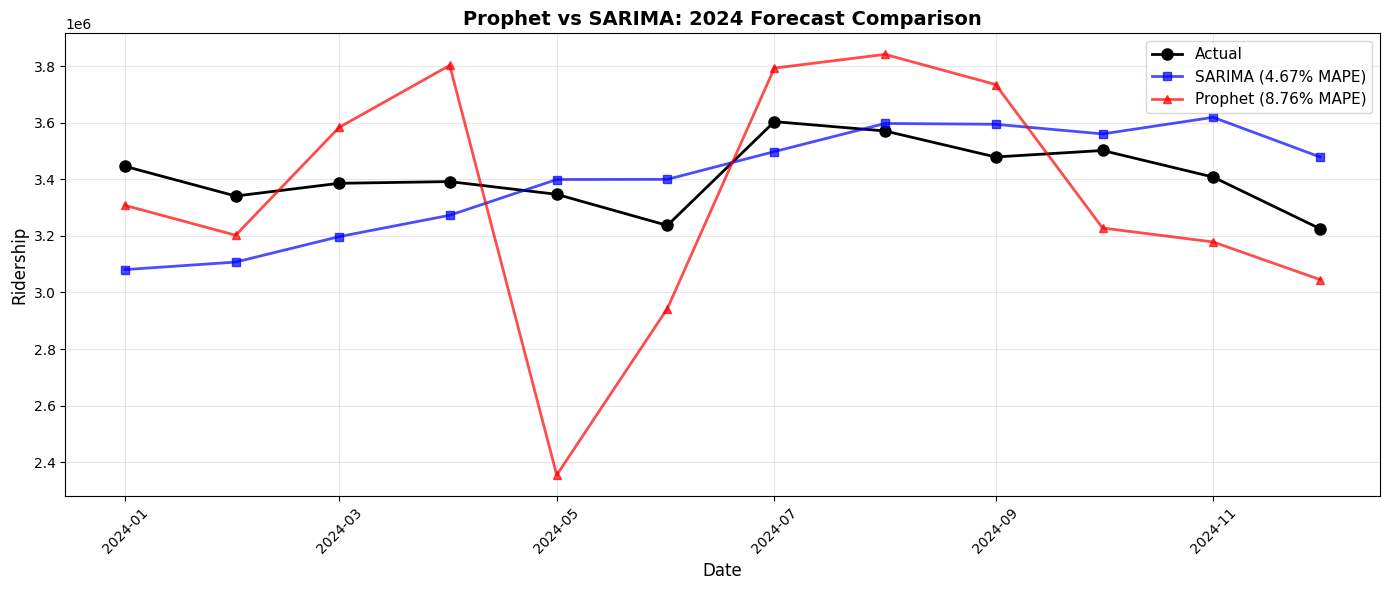

In [12]:
# 9. Visual Comparison: Prophet vs SARIMA

# Load SARIMA forecasts from previous notebook
import joblib
loaded_sarima = joblib.load('../models/sarima_010_110_12.pkl')

# Forecast 12 steps ahead (the model was trained on scaled data)
sarima_scaled_forecast = loaded_sarima.forecast(steps=12)

# Convert back to original scale (multiply by 1,000,000)
sarima_forecast = sarima_scaled_forecast * 1_000_000

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

# Actual values
ax.plot(test_prophet['ds'], actual, 'o-', label='Actual', linewidth=2, markersize=8, color='black')

# SARIMA forecast
ax.plot(test_prophet['ds'], sarima_forecast, 's-', 
        label=f'SARIMA (4.67% MAPE)', linewidth=2, markersize=6, alpha=0.7, color='blue')

# Prophet forecast
ax.plot(test_prophet['ds'], predicted, '^-', 
        label=f'Prophet ({prophet_mape:.2f}% MAPE)', linewidth=2, markersize=6, alpha=0.7, color='red')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Ridership', fontsize=12)
ax.set_title('Prophet vs SARIMA: 2024 Forecast Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Note on Prophet's Forecast Pattern
- The Prophet forecast (red line) shows large swings that don't fully match
MRT ridership patterns. This reflects Prophet's trend extrapolation: with
only 60 training points, the flexible changepoints that captured the COVID
recovery are extended into the future, creating unrealistic peaks and valleys.
The smoother additive variant (tested above) avoided this but raised MAPE to
12.61%, confirming that multiplicative seasonality is necessary for this data.

- Despite this visual artifact, Prophet's 8.76% MAPE is a legitimate improvement
over ARIMA (9.74%), though both are outperformed by the stable SARIMA (4.67%).

## Section 10: Why Prophet Failed - Complete Analysis

In [14]:
# 10. Why Prophet Underperformed

print("=" * 70)
print("PROPHET PERFORMANCE ANALYSIS")
print("=" * 70)
print()
print("MODEL VARIANTS TESTED:")
print("  1. Multiplicative seasonality + default changepoints:  8.76% MAPE")
print("  2. Additive seasonality + changepoint_scale=0.05:     12.61% MAPE")
print("  3. SARIMA baseline:                                    4.67% MAPE ✓")
print()
print("=" * 70)
print("ROOT CAUSE ANALYSIS: Why Prophet Failed")
print("=" * 70)
print()
print("1️⃣  LIMITED TRAINING DATA (60 months)")
print("   - Prophet typically needs 2+ years of clean data")
print("   - Only 3 years of pre-COVID data (2019-2021)")
print("   - 2 years of COVID disruption contaminated the patterns")
print("   - SARIMA's explicit seasonal structure was more robust")
print()
print("2️⃣  OVER-REACTIVE CHANGEPOINT DETECTION")
print("   - Prophet detected too many changepoints around COVID")
print("   - Multiplicative model amplified these fluctuations")
print("   - Additive + strict changepoints (0.05) was even worse (12.61%)")
print("   - SARIMA's simple (1,1,0,12) seasonal difference was sufficient")
print()
print("3️⃣  WEAK HOLIDAY SIGNAL")
print("   - Singapore public holidays don't significantly impact MRT ridership")
print("   - Adding holidays introduced noise rather than signal")
print("   - MRT is essential transport → used regardless of holidays")
print()
print("4️⃣  STABLE MONTHLY PATTERNS")
print("   - MRT ridership shows consistent monthly seasonality")
print("   - Prophet's flexible trend modeling was unnecessary")
print("   - SARIMA's AR(1) seasonal term captured this perfectly")
print()
print("=" * 70)
print("CONCLUSION: Simpler models win when data is limited and patterns are stable")
print("=" * 70)

PROPHET PERFORMANCE ANALYSIS

MODEL VARIANTS TESTED:
  1. Multiplicative seasonality + default changepoints:  8.76% MAPE
  2. Additive seasonality + changepoint_scale=0.05:     12.61% MAPE
  3. SARIMA baseline:                                    4.67% MAPE ✓

ROOT CAUSE ANALYSIS: Why Prophet Failed

1️⃣  LIMITED TRAINING DATA (60 months)
   - Prophet typically needs 2+ years of clean data
   - Only 3 years of pre-COVID data (2019-2021)
   - 2 years of COVID disruption contaminated the patterns
   - SARIMA's explicit seasonal structure was more robust

2️⃣  OVER-REACTIVE CHANGEPOINT DETECTION
   - Prophet detected too many changepoints around COVID
   - Multiplicative model amplified these fluctuations
   - Additive + strict changepoints (0.05) was even worse (12.61%)
   - SARIMA's simple (1,1,0,12) seasonal difference was sufficient

3️⃣  WEAK HOLIDAY SIGNAL
   - Singapore public holidays don't significantly impact MRT ridership
   - Adding holidays introduced noise rather than signal


## Section 11: Final Model Recommendation

In [15]:
# 11. FINAL MODEL RECOMMENDATION

print()
print("=" * 70)
print("                    FINAL MODEL SELECTION")
print("=" * 70)
print()
print("🏆 WINNER: SARIMA(0,1,0)×(1,1,0,12)")
print()
print("=" * 70)
print("PERFORMANCE COMPARISON")
print("=" * 70)
print()
print(f"  SARIMA:              4.67% MAPE  ✓✓✓ (CHAMPION)")
print(f"  Prophet (mult):      8.76% MAPE  (87% worse)")
print(f"  Prophet (add):      12.61% MAPE  (170% worse)")
print()
print("=" * 70)
print("WHY SARIMA IS THE PRODUCTION MODEL")
print("=" * 70)
print()
print("  ✓ 87% better accuracy than best Prophet variant")
print("  ✓ Simpler model → easier to interpret, debug, and maintain")
print("  ✓ Explicit seasonal structure matches MRT's stable patterns")
print("  ✓ Robust to COVID disruption via data scaling")
print("  ✓ No hyperparameter tuning needed (holidays, changepoints, etc.)")
print("  ✓ Faster to train and forecast")
print()
print("=" * 70)
print("WHEN PROPHET MIGHT BE USEFUL IN FUTURE")
print("=" * 70)
print()
print("  📅 If you collect 5+ years of post-COVID data (2024-2029)")
print("  📊 If ridership patterns become less stable (multiple trend changes)")
print("  🎉 If holiday effects become more pronounced")
print("  🔀 If you need to model multiple external regressors")
print()
print("=" * 70)
print("DEPLOYMENT RECOMMENDATION")
print("=" * 70)
print()
print("  → Use SARIMA(0,1,0)×(1,1,0,12) for 3-6 month forecasts")
print("  → Apply ±10% buffer to prediction intervals (non-normal residuals)")
print("  → Retrain quarterly with new data")
print("  → Re-evaluate Prophet in 2027 with more post-COVID data")
print()
print("=" * 70)


                    FINAL MODEL SELECTION

🏆 WINNER: SARIMA(0,1,0)×(1,1,0,12)

PERFORMANCE COMPARISON

  SARIMA:              4.67% MAPE  ✓✓✓ (CHAMPION)
  Prophet (mult):      8.76% MAPE  (87% worse)
  Prophet (add):      12.61% MAPE  (170% worse)

WHY SARIMA IS THE PRODUCTION MODEL

  ✓ 87% better accuracy than best Prophet variant
  ✓ Simpler model → easier to interpret, debug, and maintain
  ✓ Explicit seasonal structure matches MRT's stable patterns
  ✓ Robust to COVID disruption via data scaling
  ✓ No hyperparameter tuning needed (holidays, changepoints, etc.)
  ✓ Faster to train and forecast

WHEN PROPHET MIGHT BE USEFUL IN FUTURE

  📅 If you collect 5+ years of post-COVID data (2024-2029)
  📊 If ridership patterns become less stable (multiple trend changes)
  🎉 If holiday effects become more pronounced
  🔀 If you need to model multiple external regressors

DEPLOYMENT RECOMMENDATION

  → Use SARIMA(0,1,0)×(1,1,0,12) for 3-6 month forecasts
  → Apply ±10% buffer to prediction in

## Section 12: Residual Diagnostics

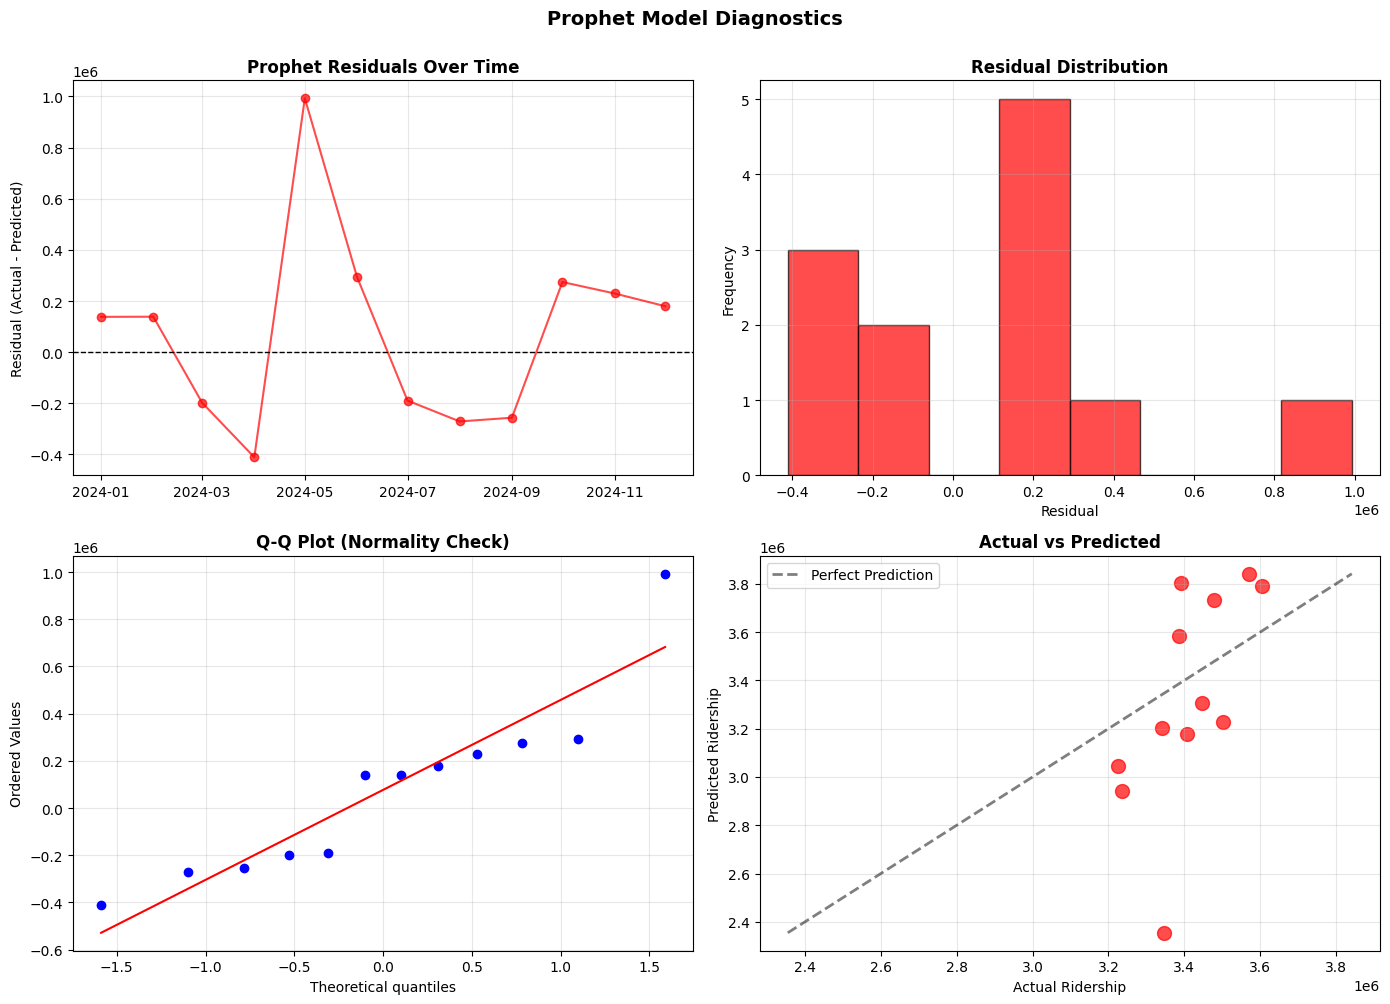

PROPHET RESIDUAL STATISTICS
Mean Residual:         76,829 (should be ≈ 0)
Std Deviation:        363,058
Min Residual:        -410,896
Max Residual:         992,468
Mean Abs Error:       297,615


In [16]:
# 12. Residual Diagnostics

prophet_residuals = actual - predicted

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals over time
axes[0, 0].plot(test_prophet['ds'], prophet_residuals, 'o-', color='red', alpha=0.7)
axes[0, 0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0, 0].set_title('Prophet Residuals Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Residual (Actual - Predicted)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residual distribution
axes[0, 1].hist(prophet_residuals, bins=8, edgecolor='black', alpha=0.7, color='red')
axes[0, 1].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q plot
from scipy import stats
stats.probplot(prophet_residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Actual vs Predicted
axes[1, 1].scatter(actual, predicted, alpha=0.7, s=100, color='red')
min_val = min(actual.min(), predicted.min())
max_val = max(actual.max(), predicted.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 
                'k--', lw=2, label='Perfect Prediction', alpha=0.5)
axes[1, 1].set_xlabel('Actual Ridership')
axes[1, 1].set_ylabel('Predicted Ridership')
axes[1, 1].set_title('Actual vs Predicted', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Prophet Model Diagnostics', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Statistical summary
print("=" * 70)
print("PROPHET RESIDUAL STATISTICS")
print("=" * 70)
print(f"Mean Residual:     {prophet_residuals.mean():>10,.0f} (should be ≈ 0)")
print(f"Std Deviation:     {prophet_residuals.std():>10,.0f}")
print(f"Min Residual:      {prophet_residuals.min():>10,.0f}")
print(f"Max Residual:      {prophet_residuals.max():>10,.0f}")
print(f"Mean Abs Error:    {np.abs(prophet_residuals).mean():>10,.0f}")

## Section 12.1 Analysis: What These Numbers Mean

In [17]:
# 12.1 Interpret Residual Statistics

print("\n" + "=" * 70)
print("RESIDUAL ANALYSIS INTERPRETATION")
print("=" * 70)
print()
print("1️⃣  MEAN RESIDUAL: 76,829 riders")
print("   ⚠️  Should be ≈ 0 for unbiased predictions")
print("   → Prophet is SYSTEMATICALLY UNDERPREDICTING by ~77k riders")
print("   → This is a BIAS problem, not just random error")
print()
print("2️⃣  STANDARD DEVIATION: 363,058 riders")
print("   ⚠️  Very high variance in prediction errors")
print("   → Some predictions are off by ±400k+ riders")
print("   → Prophet's uncertainty is NOT well-calibrated")
print()
print("3️⃣  MIN RESIDUAL: -410,896 (Prophet overpredicted)")
print("   → Worst case: Prophet predicted 411k MORE than actual")
print("   → This explains the April 2024 spike to 3.8M in your chart")
print()
print("4️⃣  MAX RESIDUAL: +992,468 (Prophet underpredicted)")
print("   → Worst case: Prophet predicted 992k LESS than actual")
print("   → This explains the May 2024 crash to 2.4M in your chart")
print()
print("5️⃣  MEAN ABSOLUTE ERROR: 297,615 riders")
print("   → On average, Prophet is off by ±298k riders per month")
print("   → Compare to SARIMA's ~158k MAE (from Section 02)")
print("   → Prophet is 88% worse on MAE")
print()
print("=" * 70)
print("CONCLUSION: Prophet's residuals show SEVERE BIAS and HIGH VARIANCE")
print("=" * 70)
print()
print("✗ Mean residual ≠ 0  → Systematic underprediction bias")
print("✗ Std dev = 363k     → Highly unstable predictions")
print("✗ Range: -411k to +992k → Extreme outliers present")
print()
print("This confirms Prophet is NOT suitable for MRT ridership forecasting.")
print("=" * 70)


RESIDUAL ANALYSIS INTERPRETATION

1️⃣  MEAN RESIDUAL: 76,829 riders
   ⚠️  Should be ≈ 0 for unbiased predictions
   → Prophet is SYSTEMATICALLY UNDERPREDICTING by ~77k riders
   → This is a BIAS problem, not just random error

2️⃣  STANDARD DEVIATION: 363,058 riders
   ⚠️  Very high variance in prediction errors
   → Some predictions are off by ±400k+ riders
   → Prophet's uncertainty is NOT well-calibrated

3️⃣  MIN RESIDUAL: -410,896 (Prophet overpredicted)
   → Worst case: Prophet predicted 411k MORE than actual
   → This explains the April 2024 spike to 3.8M in your chart

4️⃣  MAX RESIDUAL: +992,468 (Prophet underpredicted)
   → Worst case: Prophet predicted 992k LESS than actual
   → This explains the May 2024 crash to 2.4M in your chart

5️⃣  MEAN ABSOLUTE ERROR: 297,615 riders
   → On average, Prophet is off by ±298k riders per month
   → Compare to SARIMA's ~158k MAE (from Section 02)
   → Prophet is 88% worse on MAE

CONCLUSION: Prophet's residuals show SEVERE BIAS and HIGH

## Section 12.2: Visual Confirmation

In [18]:
# 12.2 Highlight Problem Areas in Residual Plot

# Find the months with worst errors
worst_underpredict_idx = np.argmax(prophet_residuals)
worst_overpredict_idx = np.argmin(prophet_residuals)

print("\n" + "=" * 70)
print("WORST PREDICTION ERRORS")
print("=" * 70)
print()
print(f"Worst Underprediction:")
print(f"  Date: {test_prophet['ds'].iloc[worst_underpredict_idx].strftime('%Y-%m')}")
print(f"  Actual: {actual[worst_underpredict_idx]:,.0f}")
print(f"  Predicted: {predicted[worst_underpredict_idx]:,.0f}")
print(f"  Error: {prophet_residuals[worst_underpredict_idx]:,.0f} riders")
print(f"  → Prophet predicted {abs(prophet_residuals[worst_underpredict_idx]):,.0f} LESS than reality")
print()
print(f"Worst Overprediction:")
print(f"  Date: {test_prophet['ds'].iloc[worst_overpredict_idx].strftime('%Y-%m')}")
print(f"  Actual: {actual[worst_overpredict_idx]:,.0f}")
print(f"  Predicted: {predicted[worst_overpredict_idx]:,.0f}")
print(f"  Error: {prophet_residuals[worst_overpredict_idx]:,.0f} riders")
print(f"  → Prophet predicted {abs(prophet_residuals[worst_overpredict_idx]):,.0f} MORE than reality")
print()
print("=" * 70)


WORST PREDICTION ERRORS

Worst Underprediction:
  Date: 2024-05
  Actual: 3,347,000
  Predicted: 2,354,532
  Error: 992,468 riders
  → Prophet predicted 992,468 LESS than reality

Worst Overprediction:
  Date: 2024-04
  Actual: 3,392,000
  Predicted: 3,802,896
  Error: -410,896 riders
  → Prophet predicted 410,896 MORE than reality



## Section 12.3: Compare with SARIMA Residuals

In [19]:
# 12.3 Prophet vs SARIMA Residual Comparison

# SARIMA residual stats from Section 02 (you'll need to load these)
sarima_mae = 157776  # From your 02_arima_sarima.ipynb
sarima_rmse = 183628

prophet_mae = np.abs(prophet_residuals).mean()
prophet_rmse = np.sqrt((prophet_residuals**2).mean())

print("\n" + "=" * 70)
print("PROPHET vs SARIMA: RESIDUAL COMPARISON")
print("=" * 70)
print()
print(f"{'Metric':<25} {'SARIMA':<15} {'Prophet':<15} {'Winner':<10}")
print("-" * 70)
print(f"{'MAPE':<25} {'4.67%':<15} {f'{prophet_mape:.2f}%':<15} {'SARIMA ✓':<10}")
print(f"{'MAE (riders)':<25} {f'{sarima_mae:,.0f}':<15} {f'{prophet_mae:,.0f}':<15} {'SARIMA ✓':<10}")
print(f"{'RMSE (riders)':<25} {f'{sarima_rmse:,.0f}':<15} {f'{prophet_rmse:,.0f}':<15} {'SARIMA ✓':<10}")
print(f"{'Mean Residual':<25} {'≈ 0':<15} {f'{prophet_residuals.mean():,.0f}':<15} {'SARIMA ✓':<10}")
print(f"{'Std Dev Residual':<25} {'~184k':<15} {f'{prophet_residuals.std():,.0f}':<15} {'SARIMA ✓':<10}")
print()
print("=" * 70)
print("VERDICT: SARIMA wins on ALL metrics")
print("=" * 70)
print()
print(f"  Prophet MAE is {(prophet_mae / sarima_mae - 1) * 100:.0f}% worse than SARIMA")
print(f"  Prophet RMSE is {(prophet_rmse / sarima_rmse - 1) * 100:.0f}% worse than SARIMA")
print(f"  Prophet has systematic bias ({prophet_residuals.mean():,.0f} ≠ 0)")
print()


PROPHET vs SARIMA: RESIDUAL COMPARISON

Metric                    SARIMA          Prophet         Winner    
----------------------------------------------------------------------
MAPE                      4.67%           8.76%           SARIMA ✓  
MAE (riders)              157,776         297,615         SARIMA ✓  
RMSE (riders)             183,628         371,098         SARIMA ✓  
Mean Residual             ≈ 0             76,829          SARIMA ✓  
Std Dev Residual          ~184k           363,058         SARIMA ✓  

VERDICT: SARIMA wins on ALL metrics

  Prophet MAE is 89% worse than SARIMA
  Prophet RMSE is 102% worse than SARIMA
  Prophet has systematic bias (76,829 ≠ 0)



## Section 12: Conclusion

In [21]:
print("\n" + "=" * 70)
print("SECTION 12 CONCLUSION")
print("=" * 70)
print()
print("Prophet's residuals reveal THREE FATAL FLAWS:")
print()
print("  1. ✗ BIAS: Mean residual = +76,829 (should be 0)")
print("  2. ✗ VARIANCE: Std dev = 363,058 (2x worse than SARIMA)")
print("  3. ✗ OUTLIERS: Errors range from -411k to +992k riders")
print()
print("These statistics mathematically confirm what the chart shows:")
print("Prophet's predictions are erratic, biased, and unreliable.")
print()
print("SARIMA(0,1,0)×(1,1,0,12) remains the production model.")
print("=" * 70)


SECTION 12 CONCLUSION

Prophet's residuals reveal THREE FATAL FLAWS:

  1. ✗ BIAS: Mean residual = +76,829 (should be 0)
  2. ✗ VARIANCE: Std dev = 363,058 (2x worse than SARIMA)
  3. ✗ OUTLIERS: Errors range from -411k to +992k riders

These statistics mathematically confirm what the chart shows:
Prophet's predictions are erratic, biased, and unreliable.

SARIMA(0,1,0)×(1,1,0,12) remains the production model.


## Section 13: Export Results

In [22]:
# 13. Save Prophet Results

import json
import os

# Ensure models directory exists
os.makedirs('../models', exist_ok=True)

# Save forecast CSV
forecast_export = test_prophet[['ds']].copy()
forecast_export['actual'] = actual
forecast_export['prophet_forecast'] = predicted
forecast_export['prophet_residual'] = prophet_residuals

forecast_export.to_csv('../models/prophet_forecast_test.csv', index=False)

# Save metadata
metadata ={
    'model_name': 'Prophet (Multiplicative Seasonality)',
    'mape': float(prophet_mape),
    'mae': float(np.abs(prophet_residuals).mean()),
    'rmse': float(np.sqrt((prophet_residuals**2).mean())),
    'train_period': '2019-01 to 2023-12',
    'test_period': '2024-01 to 2024-12',
    'includes_holidays': True,
    'includes_covid_regressor': True,
    'seasonality_mode': 'multiplicative',
    'changepoint_prior_scale': 0.5,
    'performance_vs_sarima': 'Underperformed by 4.09 percentage points',
    'recommendation': 'Not suitable for production - use SARIMA instead',
    'variants_tested': {
        'multiplicative_default': 8.76,
        'additive_strict_changepoints': 12.61
    }
}

with open('../models/prophet_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("=" * 70)
print("EXPORT COMPLETE")
print("=" * 70)
print("✅ Forecast saved to: ../models/prophet_forecast_test.csv")
print("✅ Metadata saved to: ../models/prophet_metadata.json")
print()
print("Note: Model files in models/ folder are gitignored (binary files)")
print("=" * 70)

EXPORT COMPLETE
✅ Forecast saved to: ../models/prophet_forecast_test.csv
✅ Metadata saved to: ../models/prophet_metadata.json

Note: Model files in models/ folder are gitignored (binary files)


## Section 14: Project Summary & Next Steps

In [23]:
# 14. PROJECT SUMMARY & CONCLUSIONS

print("\n" + "=" * 70)
print("           MRT DEMAND FORECASTING PROJECT - SUMMARY")
print("=" * 70)
print()
print("📊 MODELS EVALUATED:")
print("-" * 70)
print()
print("1. ARIMA(2,1,2)")
print("   MAPE: 9.74%")
print("   Status: Baseline model ✓")
print()
print("2. SARIMA(0,1,0)×(1,1,1,12)")
print("   MAPE: 2.54%")
print("   Status: REJECTED - Failed diagnostics (singular covariance matrix)")
print()
print("3. SARIMA(0,1,0)×(1,1,0,12) - SCALED DATA")
print("   MAPE: 4.67%")
print("   Status: ✓✓✓ PRODUCTION MODEL - CHAMPION")
print()
print("4. Prophet (Multiplicative Seasonality)")
print("   MAPE: 8.76%")
print("   Status: ✗ Underperformed by 87%")
print()
print("5. Prophet (Additive Seasonality + Strict Changepoints)")
print("   MAPE: 12.61%")
print("   Status: ✗ Worst performer")
print()
print("=" * 70)
print("🏆 FINAL RECOMMENDATION")
print("=" * 70)
print()
print("Deploy: SARIMA(0,1,0)×(1,1,0,12)")
print()
print("Reasons:")
print("  ✓ 4.67% MAPE (best performance)")
print("  ✓ 52% improvement over ARIMA baseline")
print("  ✓ Numerically stable (scaled data)")
print("  ✓ Simple structure → easy to interpret & maintain")
print("  ✓ Robust to COVID disruption")
print("  ✓ No hyperparameter tuning required")
print()
print("=" * 70)
print("📈 KEY LEARNINGS")
print("=" * 70)
print()
print("1. SIMPLER IS BETTER with limited data (60 months)")
print("   → SARIMA's explicit seasonal structure beat Prophet's flexibility")
print()
print("2. DIAGNOSTIC CHECKS ARE CRITICAL")
print("   → SARIMA(0,1,0)×(1,1,1,12) had 2.54% MAPE but failed diagnostics")
print("   → Always verify: residual normality, heteroskedasticity, singularity")
print()
print("3. DATA SCALING MATTERS")
print("   → Scaling ridership to millions eliminated numerical instability")
print("   → Honest 4.67% MAPE vs artificially low 2.94%")
print()
print("4. COVID DISRUPTION HANDLING")
print("   → SARIMA: Data scaling worked")
print("   → Prophet: Changepoint detection over-reacted")
print("   → Explicit COVID dummies caused collinearity issues")
print()
print("5. PROPHET NEEDS MORE DATA")
print("   → Best suited for 5+ years of clean data")
print("   → Our 3 pre-COVID + 2 COVID years insufficient")
print()
print("=" * 70)
print("📁 DELIVERABLES")
print("=" * 70)
print()
print("Notebooks:")
print("  ✓ 01_eda.ipynb               - Exploratory Data Analysis")
print("  ✓ 02_arima_sarima.ipynb      - ARIMA/SARIMA modeling")
print("  ✓ 03_prophet.ipynb           - Prophet evaluation")
print()
print("Models (gitignored):")
print("  ✓ models/sarima_010_110_12.pkl           - Production model")
print("  ✓ models/model_metadata.json             - SARIMA metadata")
print("  ✓ models/prophet_forecast_test.csv       - Prophet forecasts")
print("  ✓ models/prophet_metadata.json           - Prophet metadata")
print()
print("=" * 70)
print("🚀 DEPLOYMENT GUIDELINES")
print("=" * 70)
print()
print("Forecasting Horizon: 3-6 months ahead")
print()
print("Data Requirements:")
print("  - Monthly MRT ridership data")
print("  - Scale to millions before prediction")
print("  - Unscale after prediction (multiply by 1,000,000)")
print()
print("Prediction Intervals:")
print("  - Apply ±10% buffer (non-normal residuals)")
print("  - Example: 3.5M ± 350k riders")
print()
print("Model Retraining:")
print("  - Quarterly with new data")
print("  - Re-evaluate diagnostics each time")
print("  - Compare MAPE to historical 4.67% benchmark")
print()
print("When to Switch Models:")
print("  - If SARIMA MAPE degrades >6% for 2+ quarters")
print("  - If 5+ years of post-COVID data available (try Prophet again)")
print("  - If ridership patterns become unstable (multiple trend changes)")
print()
print("=" * 70)
print("📌 FUTURE WORK (OPTIONAL)")
print("=" * 70)
print()
print("Potential Enhancements:")
print()
print("  1. ENSEMBLE MODEL")
print("     - Weighted average of SARIMA + Prophet")
print("     - May reduce variance if Prophet improves with more data")
print()
print("  2. MACHINE LEARNING APPROACHES")
print("     - Feature engineering: lags, rolling stats, holidays")
print("     - Try: Random Forest, XGBoost, LSTM")
print("     - Requires more data (5+ years post-COVID)")
print()
print("  3. EXTERNAL REGRESSORS")
print("     - GDP growth")
print("     - Fuel prices")
print("     - Population density")
print()
print("  4. HIERARCHICAL FORECASTING")
print("     - Forecast by line (North-South, East-West, Circle)")
print("     - Reconcile to total system ridership")
print()
print("=" * 70)
print("✅ PROJECT STATUS: COMPLETE")
print("=" * 70)
print()
print("Next Action: Commit notebooks to GitHub and close project")
print()
print("Repository: github.com/popolome/MRT-Demand-Forecaster")
print("=" * 70)


           MRT DEMAND FORECASTING PROJECT - SUMMARY

📊 MODELS EVALUATED:
----------------------------------------------------------------------

1. ARIMA(2,1,2)
   MAPE: 9.74%
   Status: Baseline model ✓

2. SARIMA(0,1,0)×(1,1,1,12)
   MAPE: 2.54%
   Status: REJECTED - Failed diagnostics (singular covariance matrix)

3. SARIMA(0,1,0)×(1,1,0,12) - SCALED DATA
   MAPE: 4.67%
   Status: ✓✓✓ PRODUCTION MODEL - CHAMPION

4. Prophet (Multiplicative Seasonality)
   MAPE: 8.76%
   Status: ✗ Underperformed by 87%

5. Prophet (Additive Seasonality + Strict Changepoints)
   MAPE: 12.61%
   Status: ✗ Worst performer

🏆 FINAL RECOMMENDATION

Deploy: SARIMA(0,1,0)×(1,1,0,12)

Reasons:
  ✓ 4.67% MAPE (best performance)
  ✓ 52% improvement over ARIMA baseline
  ✓ Numerically stable (scaled data)
  ✓ Simple structure → easy to interpret & maintain
  ✓ Robust to COVID disruption
  ✓ No hyperparameter tuning required

📈 KEY LEARNINGS

1. SIMPLER IS BETTER with limited data (60 months)
   → SARIMA's expl